# Bank Marketing Subscription Prediction

### Machine Learning Classification Project

**Objective:** Predict whether a bank customer will subscribe to a term deposit based on customer and campaign-related information.

## Project Workflow

1. Import libraries
2. Load and understand the dataset
3. Perform data quality checks
4. Exploratory Data Analysis (EDA)
5. Analyze the target variable
6. Prepare features and target
7. Split data into training and testing sets
8. Encode categorical variables
9. Train classification models
10. Evaluate model performance
11. Analyze feature importance
12. Compare models
13. Draw final conclusions

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_csv("/content/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.shape

(45211, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].unique())


 job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

 marital
['married' 'single' 'divorced']

 education
['tertiary' 'secondary' 'unknown' 'primary']

 default
['no' 'yes']

 housing
['yes' 'no']

 loan
['no' 'yes']

 contact
['unknown' 'cellular' 'telephone']

 month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

 poutcome
['unknown' 'failure' 'other' 'success']

 y
['no' 'yes']


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


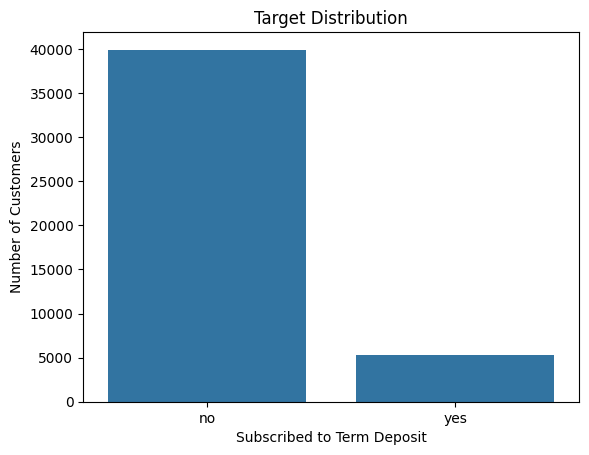

In [ ]:
sns.countplot(x="y", data=df)
plt.title("Target Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Customers")
plt.show()

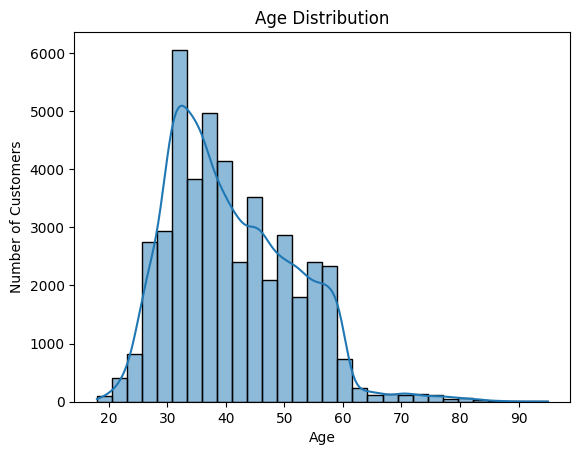

In [ ]:
sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

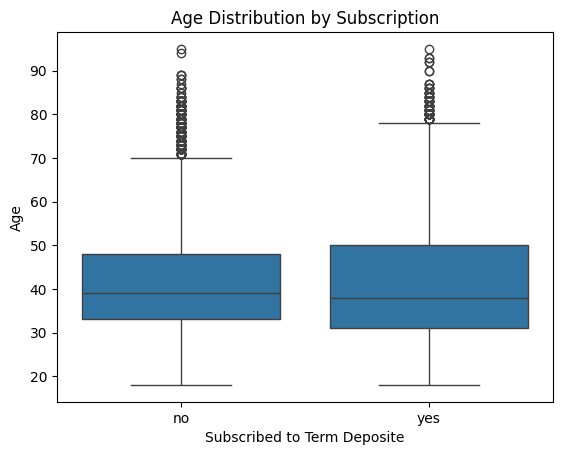

In [18]:
sns.boxplot(x="y", y="age", data=df)

plt.title("Age Distribution by Subscription")
plt.xlabel("Subscribed to Term Deposite")
plt.ylabel("Age")
plt.show()

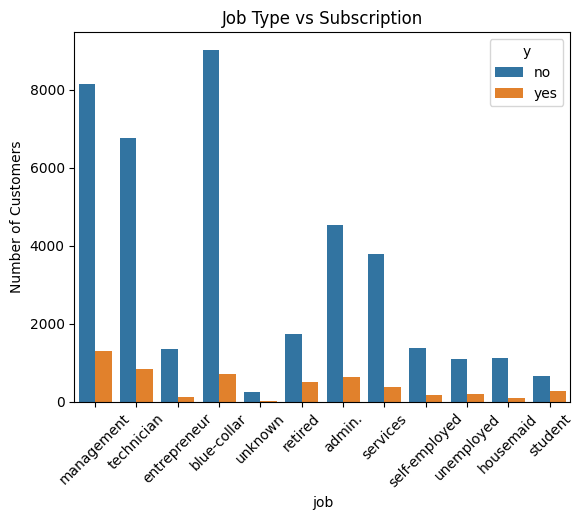

In [19]:
sns.countplot(x="job", hue="y", data=df)

plt.title("Job Type vs Subscription")
plt.xlabel("job")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()


In [20]:
job_subscription = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
) * 100

print(job_subscription)

y                     no        yes
job                                
admin.         87.797331  12.202669
blue-collar    92.725031   7.274969
entrepreneur   91.728312   8.271688
housemaid      91.209677   8.790323
management     86.244449  13.755551
retired        77.208481  22.791519
self-employed  88.157061  11.842939
services       91.116996   8.883004
student        71.321962  28.678038
technician     88.943004  11.056996
unemployed     84.497314  15.502686
unknown        88.194444  11.805556


In [21]:
education_subscription = pd.crosstab(
    df["education"],
    df["y"],
    normalize="index"
) * 100

print(education_subscription)

y                 no        yes
education                      
primary    91.373522   8.626478
secondary  89.440565  10.559435
tertiary   84.993610  15.006390
unknown    86.429725  13.570275


In [22]:
marital_subscription = pd.crosstab(
    df["marital"],
    df["y"],
    normalize="index"
) * 100

print(marital_subscription)

y                no        yes
marital                       
divorced  88.054542  11.945458
married   89.876534  10.123466
single    85.050821  14.949179


In [23]:
df[["age","balance","duration","campaign","pdays","previous"]].describe()

,age,balance,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,4918.000000,63.000000,871.000000,275.000000


In [25]:
#  preprocessing

X = df.drop("y", axis=1)
y=df["y"]

In [26]:
print(X.shape)
print(y.shape)

(45211, 16)
(45211,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print(X_train.shape)
print(X_test.shape)

(36168, 16)
(9043, 16)


In [29]:
numerical_features = [
    "age", "balance", "day", "duration",
    "campaign", "pdays", "previous"
]

categorical_features = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "poutcome"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [31]:
# Transform the data

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [32]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(36168, 51)
(9043, 51)


In [33]:
y_train_encoded = y_train.map({"no": 0, "yes": 1})
y_test_encoded = y_test.map({"no": 0, "yes": 1})

print(y_train_encoded.value_counts())
print(y_test_encoded.value_counts())

y
0    31937
1     4231
Name: count, dtype: int64
y
0    7985
1    1058
Name: count, dtype: int64


In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_encoded, y_train_encoded)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [35]:
y_pred = log_model.predict(X_test_encoded)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9010284197721995
Precision: 0.6397941680960549
Recall   : 0.35255198487712663
F1 Score : 0.45460085313833026


[[7775  210]
 [ 685  373]]


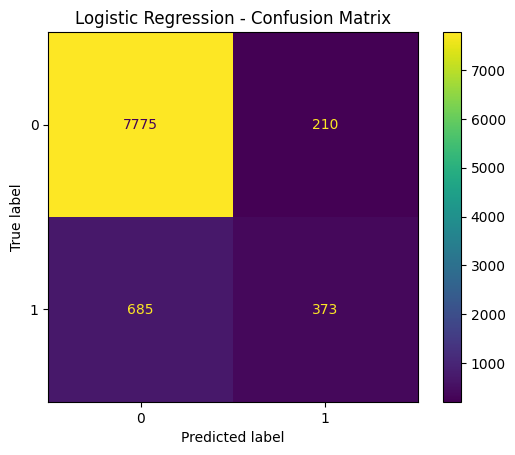

In [37]:
# confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_encoded, y_pred)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [38]:
# Desicion Tree

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

tree_model.fit(X_train_encoded, y_train_encoded)

y_pred_tree = tree_model.predict(X_test_encoded)

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test_encoded, y_pred_tree))
print("Precision:", precision_score(y_test_encoded, y_pred_tree))
print("Recall   :", recall_score(y_test_encoded, y_pred_tree))
print("F1 Score :", f1_score(y_test_encoded, y_pred_tree))

Accuracy : 0.9011390025434037
Precision: 0.6081794195250659
Recall   : 0.43572778827977315
F1 Score : 0.5077092511013216


In [40]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    class_weight="balanced"
)

rf_model.fit(X_train_encoded, y_train_encoded)

y_pred_rf = rf_model.predict(X_test_encoded)

In [41]:
print("Accuracy :", accuracy_score(y_test_encoded, y_pred_rf))
print("Precision:", precision_score(y_test_encoded, y_pred_rf))
print("Recall   :", recall_score(y_test_encoded, y_pred_rf))
print("F1 Score :", f1_score(y_test_encoded, y_pred_rf))

Accuracy : 0.8449629547716466
Precision: 0.41985088536812676
Recall   : 0.8516068052930057
F1 Score : 0.5624219725343321


In [42]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_encoded, y_train_encoded)

y_pred_gb = gb_model.predict(X_test_encoded)

In [43]:
print("Accuracy :", accuracy_score(y_test_encoded, y_pred_gb))
print("Precision:", precision_score(y_test_encoded, y_pred_gb))
print("Recall   :", recall_score(y_test_encoded, y_pred_gb))
print("F1 Score :", f1_score(y_test_encoded, y_pred_gb))

Accuracy : 0.9054517306203693
Precision: 0.6526315789473685
Recall   : 0.4102079395085066
F1 Score : 0.5037724898432966


In [44]:
# ROC-AUC

from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test_encoded)[:, 1]

roc_auc_rf = roc_auc_score(y_test_encoded, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.9182723277222296


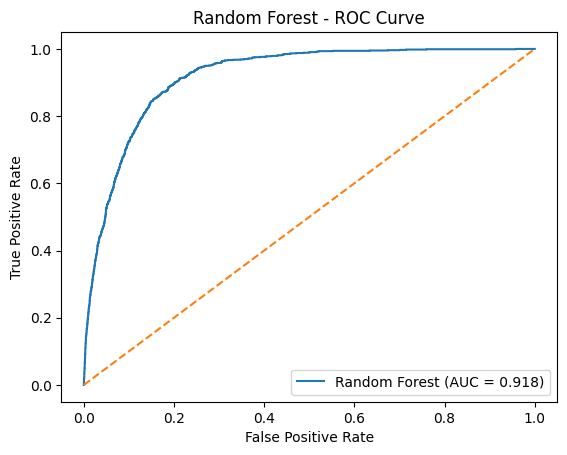

In [46]:
# ROC curve

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob_rf)

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()
plt.show()

In [47]:
# Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(15))

num__duration            0.447572
cat__poutcome_success    0.063159
cat__contact_unknown     0.048139
num__pdays               0.037583
num__age                 0.035511
cat__housing_no          0.031064
cat__housing_yes         0.029747
num__balance             0.028614
cat__contact_cellular    0.026696
num__previous            0.023595
cat__poutcome_unknown    0.023144
num__day                 0.022787
num__campaign            0.015313
cat__month_mar           0.014971
cat__month_oct           0.014410
dtype: float64


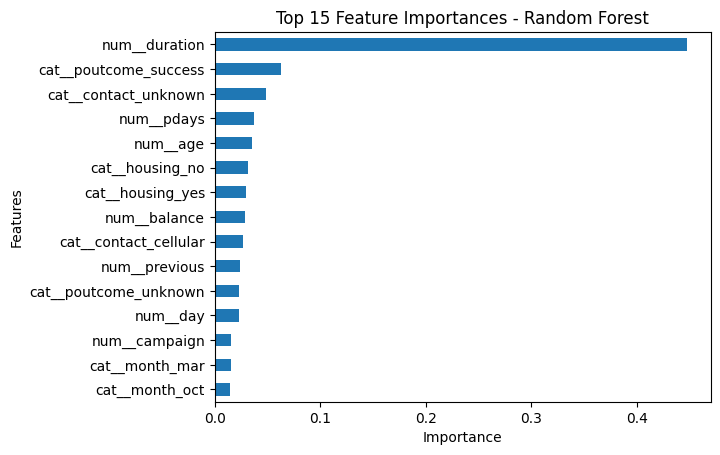

In [48]:
plt.figure()

importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importances - Random Forest")

plt.show()

In [49]:
X_no_duration = X.drop("duration", axis=1)

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_no_duration,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train_nd.shape)
print(X_test_nd.shape)

(36168, 15)
(9043, 15)


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numerical_features_nd = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous"
]

categorical_features_nd = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

preprocessor_nd = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features_nd),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_nd)
    ]
)

In [54]:
y_train_nd_encoded = y_train_nd.map({"no": 0, "yes": 1})
y_test_nd_encoded = y_test_nd.map({"no": 0, "yes": 1})

print(X_train_nd_encoded.shape)
print(X_test_nd_encoded.shape)

(36168, 50)
(9043, 50)


In [56]:
print(y_train_nd_encoded.unique())
print(y_test_nd_encoded.unique())

[0 1]
[0 1]


In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model_nd = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    max_depth=10
)

rf_model_nd.fit(X_train_nd_encoded, y_train_nd_encoded)

y_pred_rf_nd = rf_model_nd.predict(X_test_nd_encoded)

In [59]:
# Train random forest without duration

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test_nd_encoded, y_pred_rf_nd))
print("Precision:", precision_score(y_test_nd_encoded, y_pred_rf_nd))
print("Recall   :", recall_score(y_test_nd_encoded, y_pred_rf_nd))
print("F1 Score :", f1_score(y_test_nd_encoded, y_pred_rf_nd))

Accuracy : 0.8165431825721553
Precision: 0.33939070016034206
Recall   : 0.6001890359168242
F1 Score : 0.4335950836462957


[[6749 1236]
 [ 423  635]]


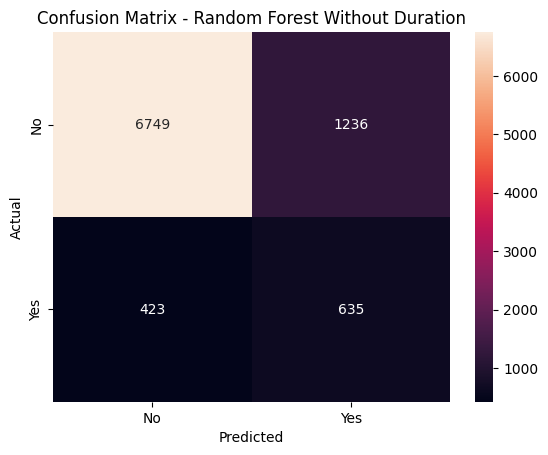

In [60]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_nd_encoded, y_pred_rf_nd)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Without Duration")
plt.show()

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest (with duration)",
        "Gradient Boosting",
        "Random Forest (without duration)"
    ],
    "Accuracy": [
        90.10,
        90.11,
        84.50,
        90.55,
        81.65
    ],
    "Precision": [
        63.98,
        68.82,
        41.96,
        65.26,
        33.94
    ],
    "Recall": [
        35.26,
        43.57,
        85.11,
        41.02,
        60.02
    ],
    "F1 Score": [
        45.46,
        50.77,
        56.24,
        50.38,
        43.36
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,90.10,63.98,35.26,45.46
1,Decision Tree,90.11,68.82,43.57,50.77
2,Random Forest (with duration),84.50,41.96,85.11,56.24
3,Gradient Boosting,90.55,65.26,41.02,50.38
4,Random Forest (without duration),81.65,33.94,60.02,43.36


## Final Findings

- The dataset is imbalanced, with more customers who did not subscribe than customers who subscribed.
- Logistic Regression, Decision Tree, and Gradient Boosting achieved accuracy around 90%.
- Random Forest with duration achieved higher recall (85.11%) and F1 score (56.24%) than the other tested models.
- However, duration represents the length of the marketing call and may not be available before or at the beginning of a customer contact. Therefore, it was excluded for a more realistic pre-call prediction scenario.
- Random Forest without duration achieved 81.65% accuracy, 33.94% precision, 60.02% recall, and 43.36% F1 score.
- The results show that removing duration changes the model's performance considerably, highlighting the importance of selecting features that are available at the time of prediction.

## Conclusion

This project developed machine learning classification models to predict whether a bank customer would subscribe to a term deposit.

The analysis included data exploration, class-imbalance analysis, categorical feature encoding, train-test splitting, model training, and evaluation using accuracy, precision, recall, and F1 score.

Multiple classification algorithms were evaluated, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

The experiment also examined the effect of the `duration` feature. Since call duration may only be known after or during customer interaction, a separate Random Forest model was trained without this feature to create a more realistic prediction scenario.

Overall, the project demonstrates how classification models can be applied to customer marketing data and how model evaluation should consider multiple metrics rather than accuracy alone.